In [ ]:
'''
Projeto 8/15 — Análise com múltiplas tabelas (JOIN)
Objetivo


Dataset
↓
Pandas
↓
Criar múltiplas tabelas
↓
SQLite
↓
Queries com JOIN
↓
Pandas
↓
Visualizações
Cenário de negócio

Vamos dividir o dataset em 3 tabelas.

Etapa 1 — Criar as tabelas

A partir do dataset Superstore, você deve criar:

Tabela 1 — Orders

Campos possíveis:

order_id
order_date
ship_date
customer_id
product_id
quantity
sales
profit
region
Tabela 2 — Customers

Campos possíveis:

customer_id
customer_name
segment
region
state
city
Tabela 3 — Products

Campos possíveis:

product_id
product_name
category
sub_category

⚠️ Importante:

Você terá que criar alguns IDs, porque o dataset não vem perfeitamente normalizado.

Isso já é uma boa prática de modelagem simples.

Etapa 2 — Criar banco SQLite

Criar banco:

ecommerce.db

E salvar as tabelas:

orders
customers
products
Etapa 3 — Validar as tabelas

Etapa 4 — Fazer JOINs

Agora começa a parte principal do projeto.

Você deve praticar:

INNER JOIN
LEFT JOIN

Exemplo conceitual:

orders
JOIN customers
JOIN products
Etapa 5 — Perguntas analíticas

Você deve responder perguntas como:

1️⃣ Qual categoria gera mais receita?


2️⃣ Qual segmento de cliente gera mais lucro?


3️⃣ Quais são os produtos mais vendidos por quantidade?


4️⃣ Qual região tem maior faturamento?


5️⃣ Quais categorias vendem mais em cada região?


Agora você já está fazendo joins múltiplos.

Etapa 6 — Trazer resultados para Pandas

Depois das queries:

SQL
↓
DataFrame

E criar visualizações.

Exemplos:

categoria x receita
segmento x lucro
região x vendas
Etapa 7 — Visualizações

Sugestões:

análise	gráfico
categoria receita	barplot
segmento lucro	barplot
região vendas	barplot
tempo vendas	lineplot
'''

'\nProjeto 8/15 — Análise com múltiplas tabelas (JOIN)\nObjetivo\n\n\nDataset\n↓\nPandas\n↓\nCriar múltiplas tabelas\n↓\nSQLite\n↓\nQueries com JOIN\n↓\nPandas\n↓\nVisualizações\nCenário de negócio\n\nVamos dividir o dataset em 3 tabelas.\n\nEtapa 1 — Criar as tabelas\n\nA partir do dataset Superstore, você deve criar:\n\nTabela 1 — Orders\n\nCampos possíveis:\n\norder_id\norder_date\nship_date\ncustomer_id\nproduct_id\nquantity\nsales\nprofit\nregion\nTabela 2 — Customers\n\nCampos possíveis:\n\ncustomer_id\ncustomer_name\nsegment\nregion\nstate\ncity\nTabela 3 — Products\n\nCampos possíveis:\n\nproduct_id\nproduct_name\ncategory\nsub_category\n\n⚠️ Importante:\n\nVocê terá que criar alguns IDs, porque o dataset não vem perfeitamente normalizado.\n\nIsso já é uma boa prática de modelagem simples.\n\nEtapa 2 — Criar banco SQLite\n\nCriar banco:\n\necommerce.db\n\nE salvar as tabelas:\n\norders\ncustomers\nproducts\nEtapa 3 — Validar as tabelas\n\nEtapa 4 — Fazer JOINs\n\nAgora começa a

In [3]:
#Ingestion
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Hyego Jarllys\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1


In [4]:
import os

arquivo= os.listdir(path)
print (f'arquivo{arquivo}')
caminho=r'C:\Users\Hyego Jarllys\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1\Sample - Superstore.csv'

arquivo['Sample - Superstore.csv']


In [5]:
#Tratamento dos dados(limpeza)
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(caminho, encoding='windows-1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.drop_duplicates()
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:

df['Ship Date']= pd.to_datetime(df["Ship Date"])
df['Order Date']= pd.to_datetime(df["Order Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [8]:
#Normalização
df_orders= df[['Order ID','Order Date','Ship Date', 'Ship Mode', 'Customer ID', 'Product ID', 'Sales','Quantity','Discount','Profit']]
df_customer=df[['Customer ID','Customer Name','Country','City','State','Postal Code', 'Region']]
df_product=df[['Product ID','Product Name','Segment','Category','Sub-Category']]

In [9]:
import sqlite3

conn=sqlite3.connect("superstore.db")
df_orders.to_sql('orders',conn, if_exists="replace", index=False)
df_customer.to_sql('customer',conn, if_exists="replace", index=False)
df_product.to_sql('product',conn, if_exists="replace", index=False) 

9994

In [14]:
query="""
select *
from orders
limit 4
"""

teste=pd.read_sql(query,conn)
teste

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310


In [12]:
query="""
select *
from customer
limit 4
"""
teste2=pd.read_sql(query,conn)
teste2

,Customer ID,Customer Name,Country,City,State,Postal Code,Region
0,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,South
1,CG-12520,Claire Gute,United States,Henderson,Kentucky,42420,South
2,DV-13045,Darrin Van Huff,United States,Los Angeles,California,90036,West
3,SO-20335,Sean O'Donnell,United States,Fort Lauderdale,Florida,33311,South


In [13]:
query="""
select *
from product
limit 4
"""
teste3=pd.read_sql(query,conn)
teste3

,Product ID,Product Name,Segment,Category,Sub-Category
0,FUR-BO-10001798,Bush Somerset Collection Bookcase,Consumer,Furniture,Bookcases
1,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Consumer,Furniture,Chairs
2,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters b...,Corporate,Office Supplies,Labels
3,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,Consumer,Furniture,Tables


In [18]:
query="""   
select p.Category, sum(o.Sales) as Total_Revenue
from Orders o
inner join product p on o."Product ID" = p."Product ID"
group by p.Category
"""

categorias=pd.read_sql_query(query,conn)
categorias

,Category,Total_Revenue
0,Furniture,5.237969e+06
1,Office Supplies,5.130507e+06
2,Technology,4.478242e+06


In [19]:
query="""   
select p.Segment, sum(o.Profit) as Total_Profit
from Orders o
inner join product p on o."Product ID" = p."Product ID"
group by p.Segment
"""
profit_segment=pd.read_sql(query,conn)
profit_segment

,Segment,Total_Profit
0,Consumer,976217.1015
1,Corporate,546649.9580
2,Home Office,379761.3298


In [39]:
query="""   
select p."Product Name", sum(o.Quantity) as Quantity
from product p
left join orders o on o."Product ID" = p."Product ID"
group by p."Product Name"
order by Quantity desc
limit 10
"""
mais_vendidos=pd.read_sql(query,conn)
mais_vendidos.head()

,Product Name,Quantity
0,Staples,1085
1,Easy-staple paper,1049
2,Staple envelope,1001
3,"Situations Contoured Folding Chairs, 4/Set",960
4,GBC Premium Transparent Covers with Diagonal L...,938


In [31]:
query="""   
select c.Region, sum(o.Sales) as Total_Revenue
from orders o
inner join customer c on c."Customer ID" = o."Customer ID"
group by c.Region
order by Total_Revenue desc
""" 
revenue_region=pd.read_sql(query,conn)
revenue_region

,Region,Total_Revenue
0,West,1.144725e+07
1,East,1.016907e+07
2,Central,8.377568e+06
3,South,5.921497e+06


In [63]:
query="""
select c.Region, p.Category, sum(o.Sales) as Total_Revenue
from orders o
inner join customer c on c."Customer ID" = o."Customer ID"
inner join product p on p."Product ID"= o."Product ID"
group by c.Region, p.Category
order by Total_Revenue desc
"""
region_category_revenue= pd.read_sql(query,conn)
region_category_revenue

,Region,Category,Total_Revenue
0,West,Office Supplies,2.645038e+07
1,West,Furniture,2.619439e+07
2,East,Furniture,2.416772e+07
3,East,Office Supplies,2.260554e+07
4,West,Technology,2.090559e+07
5,Central,Office Supplies,1.959559e+07
6,East,Technology,1.907970e+07
7,Central,Furniture,1.879726e+07
8,Central,Technology,1.633881e+07
9,South,Furniture,1.339749e+07


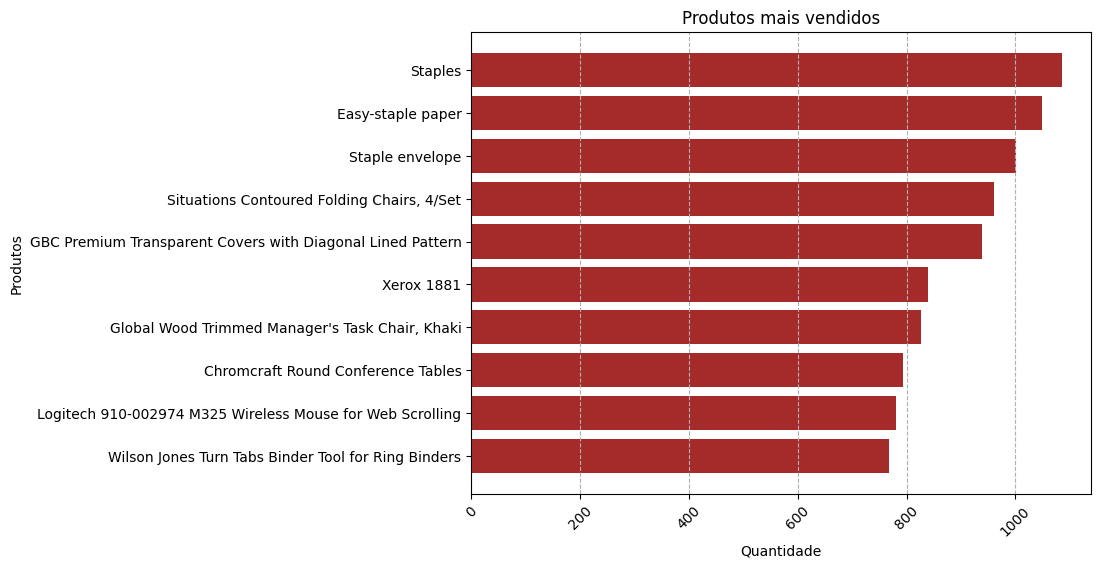

In [60]:
plt.figure(figsize=(8,6))
plt.barh(mais_vendidos['Product Name'], mais_vendidos['Quantity'], color="brown")
plt.gca().invert_yaxis()
plt.title("Produtos mais vendidos")
plt.xlabel("Quantidade")
plt.ylabel("Produtos")
plt.xticks(rotation=45)
plt.grid(True, axis='x' , linestyle='--')
plt.show()

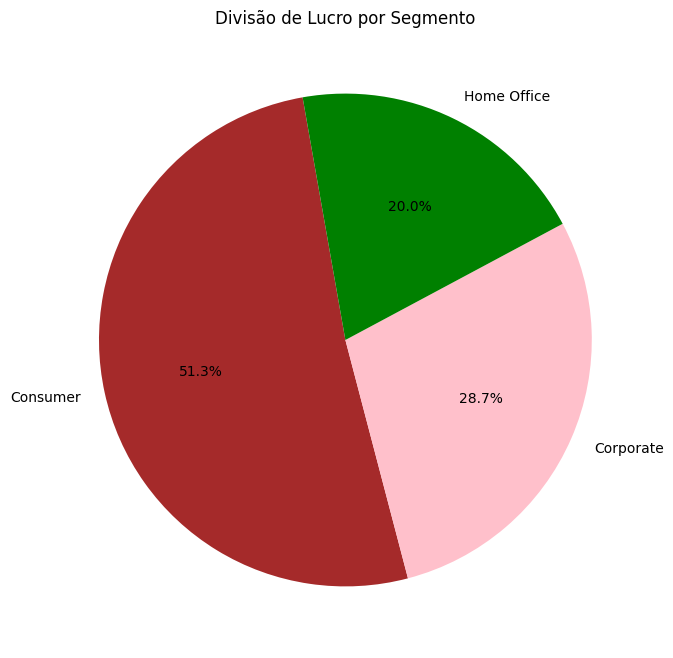

In [64]:

labels = profit_segment['Segment'] 
valores = profit_segment['Total_Profit']

plt.figure(figsize=(8, 8))

plt.pie(valores, 
        labels=labels, 
        autopct='%1.1f%%',   # Mostra a porcentagem
        startangle=100,
        colors=['brown','pink','green'])

plt.title('Divisão de Lucro por Segmento')
plt.show()

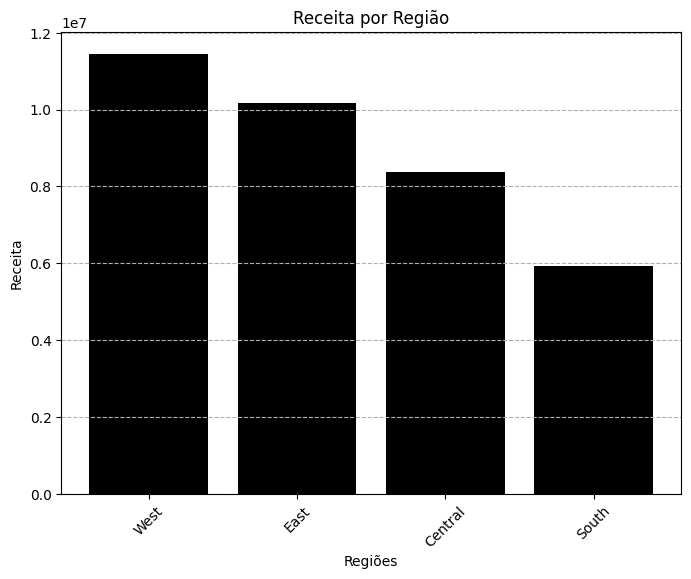

In [61]:
plt.figure(figsize=(8,6))
plt.bar(revenue_region['Region'], revenue_region['Total_Revenue'], color = 'black')
plt.title("Receita por Região")
plt.xlabel("Regiões")
plt.ylabel("Receita")
plt.grid(True, axis='y',linestyle='--')
plt.xticks(rotation=45)
plt.show()

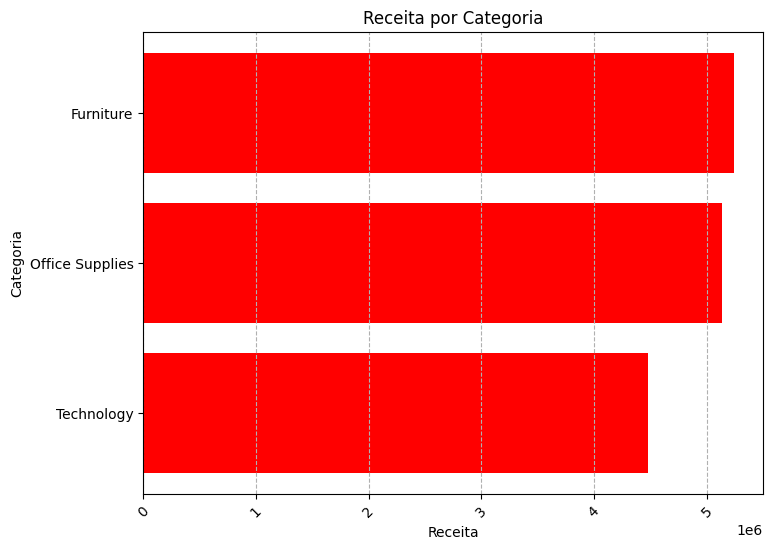

In [68]:
plt.figure(figsize=(8,6))
plt.barh(categorias["Category"], categorias["Total_Revenue"], color="Red")
plt.gca().invert_yaxis()
plt.title("Receita por Categoria")
plt.xlabel("Receita")
plt.ylabel("Categoria")
plt.xticks(rotation=45)
plt.grid(True, axis='x' , linestyle='--')
plt.show()